<h1>NEB Calculations for PBE + U</h1>

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import ase.units as units
plt.style.use("/home/jvc/ZnO_database/mpl_themes/jvc.mplstyle")

## Tratando os dados

In [6]:
print("1 kcal em eV:", units.kcal)
print("Valor do número de Avogrado:", units.mol)

1 kcal em eV: 2.611447418269555e+22
Valor do número de Avogrado: 6.022140857e+23


In [8]:
# Data from /home/jvc/ZnO_database/DFT_PBEU/NEBCalcultation/neb.out
E_fu = np.array([
-12275.8610230,
-12275.8067467,
-12275.6911943,
-12275.5638977,
-12275.4556882,
-12275.3845861,
-12275.3598450,
]) / 2

print("Energia por formula-unit (/2):\n", E_fu)

Energia por formula-unit (/2):
 [-6137.9305115  -6137.90337335 -6137.84559715 -6137.78194885
 -6137.7278441  -6137.69229305 -6137.6799225 ]


In [12]:
deltaE_fu = E_fu - E_fu.min()
deltaE_meV_fu = deltaE_fu * 1_000

print("DeltaE em meV por formula-unit:", deltaE_meV_fu)

DeltaE em meV por formula-unit: [  0.       27.13815  84.91435 148.56265 202.6674  238.21845 250.589  ]


In [13]:
fator = 1e-3 / (units.kcal / units.mol) # converte de meV/fu para kcal/mol

barreira_meV_fu = deltaE_meV_fu.max()
barreira_kcal_mol = barreira_meV_fu * fator

print("Barreira em kcal/mol:", barreira_kcal_mol)
print("Barreira em meV/fu", barreira_meV_fu)

Barreira em kcal/mol: 5.7787196657805415
Barreira em meV/fu 250.58899999930873


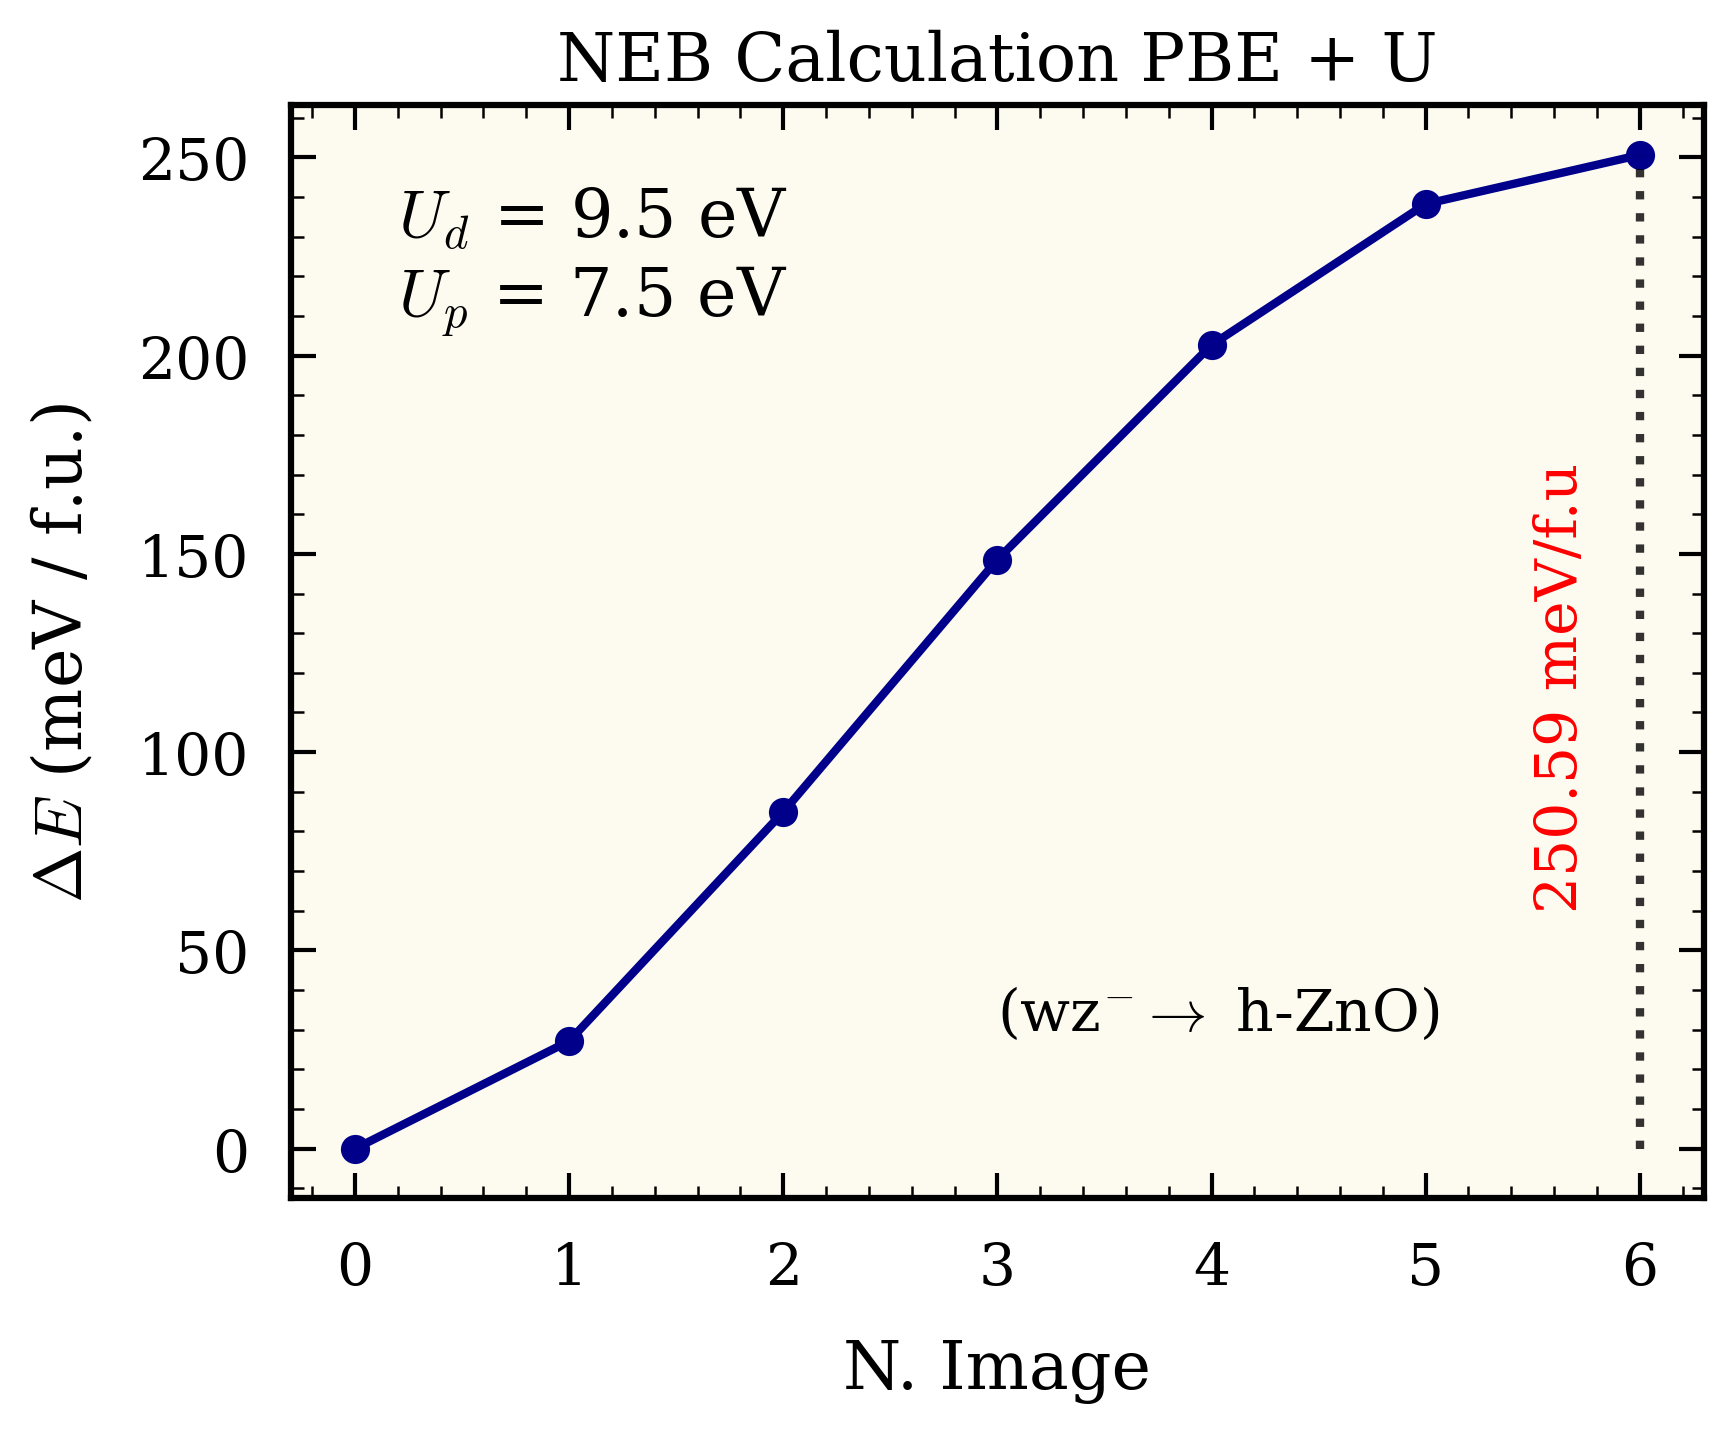

In [47]:
fig, ax = plt.subplots(dpi=300)

ax.set_title("NEB Calculation PBE + U")
ax.plot(deltaE_meV_fu, color="darkblue", marker="o")
ax.set_xlabel("N. Image")
ax.set_ylabel(r"$\Delta E$ (meV / f.u.)")


# ---
# Vertical line => activation barrier
ax.vlines(
    x=deltaE_meV_fu.argmax(),
    ymin=0,
    ymax=deltaE_meV_fu.max(),
    color="black",
    linestyle=":",
    alpha=0.8,
)
ax.text(
    s=f"{deltaE_meV_fu.max():.2f} meV/f.u",
    x=5.5,
    y=deltaE_meV_fu.max() * 0.25,
    color="red",
    rotation=90,
)
ax.text(x=3, y=30, s=r"(wz$^{-} \rightarrow$ h-ZnO)")

ax.text(s="$U_d$ = 9.5 eV", x=0.2, y=230, size=16)
ax.text(s="$U_p$ = 7.5 eV", x=0.2, y=210, size=16)
plt.show()


Qual a influência da contribuição $E_XC$ na barreira de inversão?